In [1]:
# Build a multi-step intelligent advisor system using agent workflows.

# 💼 Problem Statement
# Students need guidance on career paths based on their skills.

# Your system should:

# Analyze student profile
# Suggest career roles
# Generate learning roadmap
# 👥 Agents to Build
# Profile Analyzer Agent
# Understands student background
# Career Recommendation Agent
# Suggests suitable roles
# Skill Gap Agent
# Identifies missing skills
# Learning Path Agent
# Creates step-by-step roadmap

In [ ]:
!pip install langgraph langchain

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain.chat_models import init_chat_model

C:\Users\sk165\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 1. LLM Setup

llm = init_chat_model(model="mistral-medium")

In [ ]:
# 2. State Definition

class CareerState(TypedDict):
    profile: str
    level: str
    roles: str
    skill_gaps: str
    roadmap: str

In [ ]:
# 3. Agents

# 🔹 Profile Analyzer
def profile_analyzer(state: CareerState):
    profile = state["profile"]

    prompt = f"""
    Analyze the student profile and determine:
    1. Skill level (Beginner / Intermediate / Advanced)
    2. Key skills

    Profile: {profile}
    """

    result = llm.invoke(prompt).content

    # crude parsing (you can improve with JSON output)
    level = "Beginner"
    if "Intermediate" in result:
        level = "Intermediate"
    elif "Advanced" in result:
        level = "Advanced"

    return {"level": level}


# 🔹 Career Recommendation Agent
def career_agent(state: CareerState):
    profile = state["profile"]

    prompt = f"""
    Suggest 2-3 suitable career roles for this student.

    Profile: {profile}
    """

    roles = llm.invoke(prompt).content
    return {"roles": roles}


# 🔹 Skill Gap Agent
def skill_gap_agent(state: CareerState):
    roles = state["roles"]
    profile = state["profile"]

    prompt = f"""
    Based on the profile and roles, identify missing skills.

    Profile: {profile}
    Roles: {roles}
    """

    gaps = llm.invoke(prompt).content
    return {"skill_gaps": gaps}


# 🔹 Learning Path Agent
def learning_path_agent(state: CareerState):
    gaps = state["skill_gaps"]
    level = state["level"]

    prompt = f"""
    Create a step-by-step learning roadmap.

    Skill gaps: {gaps}
    Level: {level}

    If Beginner → start from fundamentals
    If Intermediate → focus on projects + advanced topics
    """

    roadmap = llm.invoke(prompt).content
    return {"roadmap": roadmap}

In [ ]:
# 4. Conditional Logic

def route_by_level(state: CareerState):
    if state["level"].lower() == "beginner":
        return "beginner_path"
    else:
        return "advanced_path"

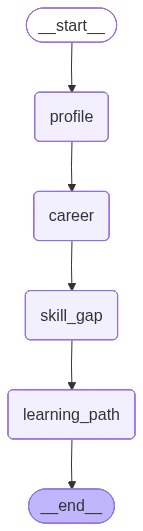

In [ ]:
# 5. Graph Construction

graph = StateGraph(CareerState)

# Nodes
graph.add_node("profile", profile_analyzer)
graph.add_node("career", career_agent)
graph.add_node("skill_gap", skill_gap_agent)
graph.add_node("learning_path", learning_path_agent)

# Flow
graph.add_edge(START, "profile")
graph.add_edge("profile", "career")
graph.add_edge("career", "skill_gap")
graph.add_edge("skill_gap","learning_path")
graph.add_edge("learning_path", END)

# Compile
workflow = graph.compile()
workflow

In [ ]:
# 6. Run Function

def run_advisor(profile_text):
    result = workflow.invoke({
        "profile": profile_text,
        "level": "",
        "roles": "",
        "skill_gaps": "",
        "roadmap": ""
    })
    return result

In [ ]:
# 7. Test Cases

profiles = [
    "I know Python basics and statistics, and I want to become a Data Scientist",
    # "I have experience in Java, databases, and backend development"
]

from IPython.display import display, Markdown
for p in profiles:
    display(Markdown(f"PROFILE: {p}"))
    output = run_advisor(p)

    display(Markdown(f"\nLevel: {output["level"]}"))
    display(Markdown(f"\nRoles: {output["roles"]}"))
    display(Markdown(f"\nSkill Gaps: {output["skill_gaps"]}"))
    display(Markdown(f"\nRoadmap: {output["roadmap"]}"))
    display(Markdown(f"="*60))

PROFILE: I know Python basics and statistics, and I want to become a Data Scientist


Level: Intermediate


Roles: Given your background in **Python basics and statistics** and your goal to become a **Data Scientist**, here are **2-3 suitable career roles** to consider as stepping stones or entry points into the field:

### **1. Data Analyst**
   - **Why?** A natural first step toward Data Science, focusing on data cleaning, visualization, and basic modeling.
   - **Skills Needed:** Python (Pandas, NumPy, Matplotlib/Seaborn), SQL, Excel, and statistical analysis.
   - **Next Steps:** Learn **SQL, Tableau/Power BI, and A/B testing** to strengthen your profile.

### **2. Business Intelligence (BI) Analyst**
   - **Why?** Bridges business needs with data insights, often using Python and statistical methods.
   - **Skills Needed:** Python (for automation & analysis), SQL, data visualization (Power BI/Tableau), and business acumen.
   - **Next Steps:** Practice **storytelling with data** and learn **dashboarding tools**.

### **3. Junior Data Scientist / Machine Learning Intern**
   - **Why?** If you’re ready to dive deeper, some companies hire juniors with Python + stats knowledge for foundational ML tasks.
   - **Skills Needed:** Python (Scikit-learn, basic ML models), statistics, and problem-solving.
   - **Next Steps:** Build **ML projects (e.g., regression, classification)** and learn **data preprocessing techniques**.

---
### **Action Plan to Transition to Data Science:**
✅ **Strengthen Python:** Master **Pandas, NumPy, Scikit-learn**.
✅ **Learn SQL:** Essential for data extraction.
✅ **Build Projects:** Kaggle, personal datasets, or freelance work.
✅ **Specialize:** Pick a domain (e.g., finance, healthcare) and learn relevant tools.

Would you like recommendations on **free/paid courses** or **project ideas** to boost your profile? 🚀


Skill Gaps: Based on your **current skills (Python basics + statistics)** and the **target roles (Data Analyst, BI Analyst, Junior Data Scientist)**, here are the **key missing skills** you should prioritize, categorized by role:

---

### **1. Universal Gaps (Applicable to All Roles)**
| **Skill**               | **Why It’s Missing**                                                                 | **How to Learn**                                                                 |
|-------------------------|-------------------------------------------------------------------------------------|----------------------------------------------------------------------------------|
| **SQL**                 | Critical for querying databases (used in 90%+ data roles).                          | Practice on [LeetCode SQL](https://leetcode.com/problemset/database/), [Mode Analytics](https://mode.com/sql-tutorial/). |
| **Data Cleaning**       | Real-world data is messy; Pandas/NumPy alone aren’t enough.                         | Work on Kaggle datasets with missing values, duplicates, or inconsistent formats. |
| **Version Control (Git)** | Essential for collaboration and project tracking.                                  | Learn via [GitHub’s guides](https://guides.github.com/) or [freeCodeCamp](https://youtu.be/RGOj5yH7evk). |
| **Storytelling with Data** | Analyzing data ≠ communicating insights effectively.                              | Study [Cole Nussbaumer Knaflic’s book](https://www.storytellingwithdata.com/) or practice explaining projects simply. |

---

### **2. Role-Specific Gaps**
#### **A. Data Analyst**
| **Skill**               | **Why It’s Missing**                                                                 | **Resources**                                                                     |
|-------------------------|-------------------------------------------------------------------------------------|----------------------------------------------------------------------------------|
| **Advanced Excel/Google Sheets** | Many teams still rely on spreadsheets for quick analysis.                          | [Excel Easy](https://www.excel-easy.com/), [Google Sheets tutorials](https://www.youtube.com/c/LeilaGharani). |
| **A/B Testing**        | Core for product/marketing analytics (e.g., testing feature impacts).              | [Google’s A/B Testing Course](https://www.coursera.org/learn/ab-testing).        |
| **Dashboarding (Tableau/Power BI)** | Static visuals (Matplotlib) ≠ interactive dashboards.                          | [Tableau Public](https://public.tableau.com/en-us/s/resources), [Power BI Guides](https://learn.microsoft.com/en-us/power-bi/guidance/). |

#### **B. Business Intelligence (BI) Analyst**
| **Skill**               | **Why It’s Missing**                                                                 | **Resources**                                                                     |
|-------------------------|-------------------------------------------------------------------------------------|----------------------------------------------------------------------------------|
| **Business Acumen**     | Need to translate data into business decisions (e.g., ROI, KPIs).                  | Follow industry reports (e.g., [McKinsey Insights](https://www.mckinsey.com/)), take a [free business course](https://www.coursera.org/learn/wharton-business-foundations). |
| **ETL Basics**          | Extract, Transform, Load (ETL) pipelines are key for BI.                            | Learn with [Talend Open Studio](https://www.talend.com/products/data-integration/) or [Apache Airflow](https://airflow.apache.org/). |
| **Advanced Visualization** | BI tools require dynamic, user-friendly visuals (e.g., drill-down charts).      | Practice with [Makeover Monday](https://www.makeovermonday.co.uk/).              |

#### **C. Junior Data Scientist / ML Intern**
| **Skill**               | **Why It’s Missing**                                                                 | **Resources**                                                                     |
|-------------------------|-------------------------------------------------------------------------------------|----------------------------------------------------------------------------------|
| **Machine Learning Fundamentals** | Beyond stats, need to implement models (e.g., regression, classification).         | [Google’s ML Crash Course](https://developers.google.com/machine-learning/crash-course), [Fast.ai](https://course.fast.ai/). |
| **Feature Engineering** | Raw data → model-ready features (e.g., scaling, encoding).                          | [Kaggle’s Feature Engineering Course](https://www.kaggle.com/learn/feature-engineering). |
| **Model Evaluation**    | Metrics like precision/recall, AUC-ROC, and cross-validation are critical.          | [Scikit-learn’s documentation](https://scikit-learn.org/stable/modules/model_evaluation.html). |
| **Big Data Basics**     | Familiarity with Spark/PySpark helps for large datasets.                            | [Databricks Academy](https://academy.databricks.com/).                           |

---

### **3. Project Ideas to Fill Gaps**
| **Role**               | **Project Idea**                                                                     | **Skills Covered**                                                                 |
|-------------------------|-------------------------------------------------------------------------------------|----------------------------------------------------------------------------------|
| **Data Analyst**        | Analyze a public dataset (e.g., [COVID-19 data](https://ourworldindata.org/covid-cases)) and create a Tableau dashboard with insights. | SQL, Tableau, storytelling.                                                      |
| **BI Analyst**          | Build a Power BI dashboard for a fake e-commerce store (sales trends, customer segmentation). | Power BI, DAX, business metrics.                                                 |
| **Junior Data Scientist** | Predict house prices using [Boston Housing dataset](https://www.kaggle.com/datasets/vikrishnan/boston-house-prices) with Scikit-learn. | ML, feature engineering, model evaluation.                                      |

---
### **4. Quick Checklist to Prioritize**
1. **Short-Term (1-3 months):**
   - Learn **SQL** (do 50+ problems on LeetCode/Mode).
   - Build **2-3 projects** (1 visualization, 1 ML, 1 BI dashboard).
   - Master **Pandas/NumPy** (solve [StrataScratch](https://www.stratascratch.com/) problems).

2. **Mid-Term (3-6 months):**
   - Learn **Git** and host projects on GitHub.
   - Take a **free ML course** (e.g., [Andrew Ng’s Coursera](https://www.coursera.org/learn/machine-learning)).
   - Practice **A/B testing** or **business case studies**.

3. **Long-Term (6+ months):**
   - Specialize in a **domain** (e.g., healthcare, finance) and learn domain-specific tools.
   - Contribute to **open-source projects** or freelance (e.g., [Upwork](https://www.upwork.com/)).
   - Prepare for **interviews** (e.g., [StrataScratch](https://www.stratascratch.com/) for SQL, [LeetCode](https://leetcode.com/) for ML).

---
### **5. Free Resources to Start Today**
- **SQL:** [SQLZoo](https://sqlzoo.net/), [Khan Academy](https://www.khanacademy.org/computing/computer-programming/sql).
- **Python for DS:** [Python for Data Science (free book)](https://wesmckinney.com/book/).
- **ML:** [Google’s ML Crash Course](https://developers.google.com/machine-learning/crash-course).
- **Projects:** [Kaggle](https://www.kaggle.com/), [DataCamp Projects](https://www.datacamp.com/projects).


Roadmap: Here’s a **structured, step-by-step learning roadmap** tailored to your current skills (Python + statistics) and target roles (Data Analyst, BI Analyst, Junior Data Scientist). The roadmap is divided into **phases**, with clear milestones, resources, and project-based learning to bridge your skill gaps.

---

## **📌 Phase 1: Foundations (1-2 Months)**
**Goal:** Strengthen core skills (SQL, data cleaning, Git) and build a portfolio foundation.

### **1. SQL (2-3 Weeks)**
- **Why?** 90% of data roles require SQL for querying databases.
- **Topics:**
  - SELECT, WHERE, GROUP BY, HAVING, JOINs (INNER, LEFT, RIGHT), Subqueries, CTEs, Window Functions.
  - Database design (normalization, primary/foreign keys).
- **Resources:**
  - Interactive: [SQLZoo](https://sqlzoo.net/), [Mode Analytics SQL Tutorial](https://mode.com/sql-tutorial/)
  - Practice: [LeetCode SQL Problems](https://leetcode.com/problemset/database/) (50+ problems)
  - Project: Query a public dataset (e.g., [Chinook Database](https://github.com/lerocha/chinook-database)) and answer business questions (e.g., "Which albums sold the most?").

### **2. Data Cleaning & EDA (2 Weeks)**
- **Why?** Real-world data is messy; Pandas/NumPy alone aren’t enough.
- **Topics:**
  - Handling missing data (imputation, dropping).
  - Outlier detection (IQR, Z-score).
  - Data transformation (scaling, encoding, datetime handling).
- **Resources:**
  - [Kaggle Pandas Course](https://www.kaggle.com/learn/pandas)
  - [Real-world datasets](https://www.kaggle.com/datasets) (e.g., Titanic, Airbnb)
- **Project:** Clean a messy dataset (e.g., [NYC Taxi Data](https://www.kaggle.com/datasets/mysarahmadbhat/nyc-taxi-trip-duration)) and perform EDA.

### **3. Version Control (Git/GitHub) (1 Week)**
- **Why?** Essential for collaboration and project tracking.
- **Topics:**
  - `git init`, `git clone`, `git add`, `git commit`, `git push`, `git pull`.
  - Branching, merging, pull requests.
- **Resources:**
  - [GitHub Guides](https://guides.github.com/)
  - [freeCodeCamp Git Tutorial](https://youtu.be/RGOj5yH7evk)
- **Action:** Upload all projects to GitHub with a clean README.

### **4. Storytelling with Data (Ongoing)**
- **Why?** Analyzing data ≠ communicating insights.
- **Resources:**
  - Book: [Storytelling with Data](https://www.storytellingwithdata.com/) (Cole Nussbaumer Knaflic)
  - Practice: Explain a project in 3 bullet points (problem, approach, insight).

---
## **📌 Phase 2: Role-Specific Skills (2-3 Months)**
**Goal:** Dive into tools and techniques for your target role(s).

### **A. Data Analyst Track**
| **Skill**               | **Topics**                                                                 | **Resources**                                                                 |
|-------------------------|---------------------------------------------------------------------------|------------------------------------------------------------------------------|
| **Advanced Excel/Google Sheets** | Pivot tables, VLOOKUP, XLOOKUP, macros, data validation.                | [Excel Easy](https://www.excel-easy.com/), [Leila Gharani (YouTube)](https://www.youtube.com/c/LeilaGharani) |
| **A/B Testing**         | Hypothesis testing, p-values, sample size calculation, multi-armed bandits. | [Google’s A/B Testing Course](https://www.coursera.org/learn/ab-testing)     |
| **Dashboarding (Tableau/Power BI)** | Connecting data, creating visuals, DAX (Power BI), parameters, storytelling. | [Tableau Public](https://public.tableau.com/en-us/s/resources), [Power BI Guides](https://learn.microsoft.com/en-us/power-bi/guidance/) |
- **Project:**
  - **Excel:** Analyze sales data and create a pivot table dashboard.
  - **Tableau/Power BI:** Build a dashboard for a fake e-commerce store (sales trends, customer segmentation).

### **B. BI Analyst Track**
| **Skill**               | **Topics**                                                                 | **Resources**                                                                 |
|-------------------------|---------------------------------------------------------------------------|------------------------------------------------------------------------------|
| **Business Acumen**     | KPIs, ROI, customer lifetime value (CLV), unit economics.                | [McKinsey Insights](https://www.mckinsey.com/), [Wharton Business Foundations (Coursera)](https://www.coursera.org/learn/wharton-business-foundations) |
| **ETL Basics**          | Extracting data (APIs, web scraping), transforming (cleaning), loading (databases). | [Talend Open Studio](https://www.talend.com/products/data-integration/), [Apache Airflow](https://airflow.apache.org/) |
| **Advanced Visualization** | Drill-down charts, tooltips, dynamic filtering.                        | [Makeover Monday](https://www.makeovermonday.co.uk/)                        |
- **Project:**
  - **ETL:** Scrape data from a website (e.g., IMDb ratings) and load it into a database.
  - **BI Dashboard:** Create a Power BI dashboard for a retail company (sales, inventory, customer demographics).

### **C. Junior Data Scientist Track**
| **Skill**               | **Topics**                                                                 | **Resources**                                                                 |
|-------------------------|---------------------------------------------------------------------------|------------------------------------------------------------------------------|
| **Machine Learning Fundamentals** | Supervised/unsupervised learning, bias-variance tradeoff, overfitting.   | [Google’s ML Crash Course](https://developers.google.com/machine-learning/crash-course), [Fast.ai](https://course.fast.ai/) |
| **Feature Engineering** | Scaling (MinMax, Standard), encoding (one-hot, label), binning.          | [Kaggle’s Feature Engineering Course](https://www.kaggle.com/learn/feature-engineering) |
| **Model Evaluation**    | Precision/recall, AUC-ROC, confusion matrix, cross-validation.           | [Scikit-learn Docs](https://scikit-learn.org/stable/modules/model_evaluation.html) |
| **Big Data Basics**     | Spark DataFrames, PySpark, distributed computing.                         | [Databricks Academy](https://academy.databricks.com/)                       |
- **Project:**
  - **ML:** Predict house prices using the [Boston Housing Dataset](https://www.kaggle.com/datasets/vikrishnan/boston-house-prices).
  - **Big Data:** Analyze a large dataset (e.g., [NYC Taxi Trips](https://www.kaggle.com/datasets/mysarahmadbhat/nyc-taxi-trip-duration)) using PySpark.

---
## **📌 Phase 3: Portfolio & Interview Prep (1-2 Months)**
**Goal:** Polish projects, practice interviews, and apply for jobs.

### **1. Portfolio Projects (Pick 2-3)**
| **Role**               | **Project Idea**                                                                 | **Skills Demonstrated**                                          |
|-------------------------|---------------------------------------------------------------------------------|------------------------------------------------------------------|
| **Data Analyst**        | Analyze COVID-19 data and create a Tableau dashboard with insights.           | SQL, Tableau, storytelling.                                     |
| **BI Analyst**          | Build a Power BI dashboard for a fake e-commerce store (sales, customer segments). | Power BI, DAX, business metrics.                               |
| **Junior Data Scientist** | Predict customer churn using a telco dataset (e.g., [Telco Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)). | ML, feature engineering, model evaluation.                     |

### **2. Interview Prep**
- **SQL:**
  - Practice on [StrataScratch](https://www.stratascratch.com/) or [LeetCode SQL](https://leetcode.com/problemset/database/).
  - Example questions: "Find the second-highest salary," "Join tables to find customer orders."
- **Python/Pandas:**
  - [StrataScratch Python Problems](https://www.stratascratch.com/)
  - Example: "Clean and aggregate sales data to find top products."
- **Behavioral:**
  - Use the **STAR method** (Situation, Task, Action, Result) for questions like "Tell me about a time you solved a problem with data."
- **Case Studies (BI/Analyst Roles):**
  - Practice on [CaseInterview.com](https://www.caseinterview.com/) or [StrataScratch](https://www.stratascratch.com/).

### **3. Apply for Jobs**
- **Where to Apply:**
  - LinkedIn, AngelList (startups), company career pages.
  - Freelance platforms: [Upwork](https://www.upwork.com/), [Toptal](https://www.toptal.com/).
- **Tailor Your Resume:**
  - Highlight **projects**, **tools** (SQL, Tableau, Python), and **impact** (e.g., "Built a dashboard that improved decision-making by X%").

---
## **📌 Phase 4: Advanced Topics (Ongoing)**
**Goal:** Specialize and stay updated.
- **Data Analyst/BI:**
  - Learn **advanced SQL** (window functions, recursive CTEs).
  - Explore **cloud tools** (BigQuery, Snowflake).
- **Junior Data Scientist:**
  - Dive into **deep learning** (TensorFlow/PyTorch) or **NLP**.
  - Learn **MLOps** (model deployment with Flask/FastAPI).
- **All Roles:**
  - Follow industry trends (e.g., [Towards Data Science](https://towardsdatascience.com/), [KDnuggets](https://www.kdnuggets.com/)).
  - Contribute to **open-source projects** (e.g., on GitHub).

---
## **📅 Sample Weekly Plan (First Month)**
| **Week** | **Focus**                          | **Tasks**                                                                 |
|----------|------------------------------------|---------------------------------------------------------------------------|
| 1        | SQL                                | Complete SQLZoo, solve 10 LeetCode problems, query Chinook Database.     |
| 2        | Data Cleaning + Git                | Clean a Kaggle dataset, upload to GitHub.                                |
| 3        | Excel/Google Sheets + A/B Testing   | Build a pivot table dashboard, start Google’s A/B Testing course.       |
| 4        | Tableau/Power BI                   | Create a dashboard using a public dataset (e.g., COVID-19).              |

---
## **🎯 Key Tips for Success**
1. **Learn by Doing:** Prioritize **projects** over passive learning (e.g., tutorials).
2. **Consistency > Speed:** Aim for **1-2 hours daily** rather than cramming.
3. **Network:** Join data communities (e.g., [Kaggle](https://www.kaggle.com/), [r/datascience](https://www.reddit.com/r/datascience/)).
4. **Tailor Your Path:** If you’re more interested in **BI**, skip deep ML and focus on **dashboarding + business acumen**.
5. **Track Progress:** Use a spreadsheet to log skills learned and projects completed.

---
## **🚀 Final Checklist Before Applying**
- [ ] **Portfolio:** 2-3 polished projects on GitHub/Tableau Public.
- [ ] **SQL:** Can write complex queries (JOINs, subqueries, window functions).
- [ ] **Tool Proficiency:** Comfortable with Python (Pandas, Scikit-learn) or BI tools (Tableau/Power BI).
- [ ] **Interview Prep:** Practiced 20+ SQL/Python problems and behavioral questions.
- [ ] **Resume:** Highlights projects, tools, and quantifiable impact.

---
### **📌 Next Steps**
1. **Pick a starting point** (e.g., SQL if you’re aiming for all roles).
2. **Block time** in your calendar (e.g., 1 hour daily).
3. **Build your first project** this week (even if it’s simple).

Would you like recommendations for **free datasets** or **project ideas** based on your interests (e.g., healthcare, finance, sports)?

============================================================